In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

base = "/content/drive/MyDrive/morph_project/processed"
print("Files inside processed:", os.listdir(base))


Files inside processed: ['batch_X_0.npy', 'batch_y_0.npy', 'batch_X_1.npy', 'batch_y_1.npy', 'batch_X_2.npy', 'batch_y_2.npy', 'batch_X_3.npy', 'batch_y_3.npy', 'batch_X_4.npy', 'batch_y_4.npy', 'batch_X_5.npy', 'batch_y_5.npy', 'batch_X_6.npy', 'batch_y_6.npy', 'batch_X_7.npy', 'batch_y_7.npy', 'batch_X_8.npy', 'batch_y_8.npy', 'batch_X_9.npy', 'batch_y_9.npy', 'batch_X_10.npy', 'batch_y_10.npy', 'batch_X_11.npy', 'batch_y_11.npy', 'batch_X_12.npy', 'batch_y_12.npy', 'batch_X_13.npy', 'batch_y_13.npy', 'batch_X_14.npy', 'batch_y_14.npy', 'batch_X_15.npy', 'batch_y_15.npy', 'batch_X_16.npy', 'batch_y_16.npy', 'batch_X_17.npy', 'batch_y_17.npy', 'batch_X_18.npy', 'batch_y_18.npy', 'X_train.npy', 'X_test.npy', 'y_test.npy', 'y_train.npy', 'train.h5', 'test.h5', 'stats.npz']


In [ ]:
import h5py
import torch
from torch.utils.data import Dataset

class H5Dataset(Dataset):
    def __init__(self, h5_path):
        self.h5 = h5py.File(h5_path, "r")
        self.X = self.h5["X"]     # (N, 224,224,3)
        self.y = self.h5["y"]     # (N,)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        img = self.X[idx]                   # already normalized
        label = self.y[idx]

        img = torch.tensor(img).permute(2,0,1)  # (C,H,W)
        label = torch.tensor(int(label), dtype=torch.long)
        return img, label


In [ ]:
train_ds = H5Dataset("/content/drive/MyDrive/morph_project/processed/train.h5")
test_ds  = H5Dataset("/content/drive/MyDrive/morph_project/processed/test.h5")

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
test_loader  = torch.utils.data.DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

len(train_ds), len(test_ds)


(7177, 1803)

In [ ]:
import timm
import torch.nn as nn
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model = timm.create_model("vit_base_patch16_224", pretrained=True)
model.head = nn.Linear(model.head.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)

from torch.cuda.amp import GradScaler, autocast
scaler = GradScaler()


Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

/tmp/ipython-input-3522592855.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [ ]:
import matplotlib.pyplot as plt

train_acc_list = []
train_loss_list = []

for epoch in range(5):
    model.train()
    correct = 0
    total = 0
    running_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        with autocast():
            out = model(imgs)
            loss = criterion(out, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds = out.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        running_loss += loss.item()

    scheduler.step()

    epoch_acc = (correct/total)*100
    epoch_loss = running_loss / len(train_loader)

    train_acc_list.append(epoch_acc)
    train_loss_list.append(epoch_loss)

    print(f"Epoch {epoch+1}/5 | Acc: {epoch_acc:.2f}% | Loss: {epoch_loss:.4f}")


/tmp/ipython-input-2778705335.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/5 | Acc: 82.85% | Loss: 0.5262
Epoch 2/5 | Acc: 82.85% | Loss: 0.5177
Epoch 3/5 | Acc: 82.85% | Loss: 0.5104
Epoch 4/5 | Acc: 82.85% | Loss: 0.5014
Epoch 5/5 | Acc: 82.81% | Loss: 0.4856


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out = model(imgs)
        preds = out.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("✅ Test Accuracy:", (correct/total)*100)


✅ Test Accuracy: 82.6955074875208


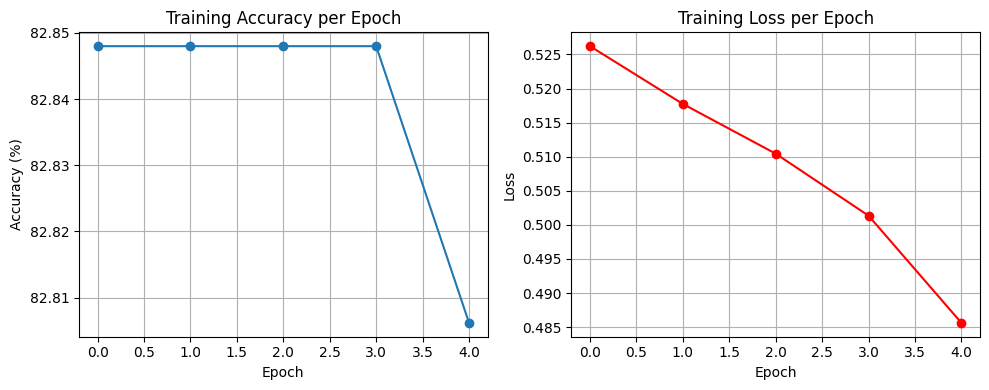

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_acc_list, marker='o')
plt.title("Training Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid()

plt.subplot(1,2,2)
plt.plot(train_loss_list, marker='o', color='red')
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

plt.tight_layout()
plt.show()


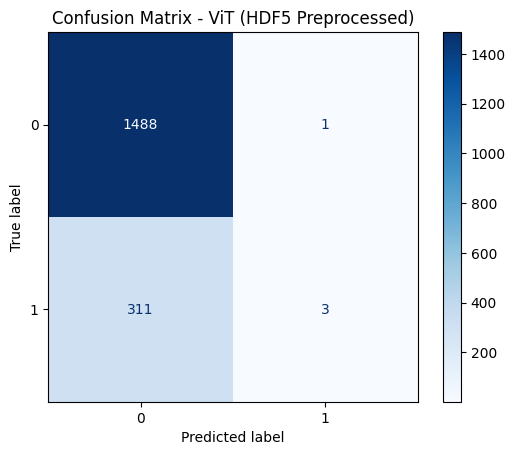

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out = model(imgs)
        preds = out.argmax(1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - ViT (HDF5 Preprocessed)")
plt.show()


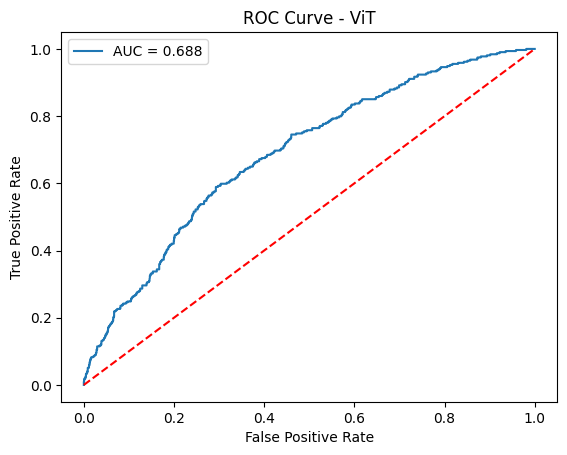

In [ ]:
from sklearn.metrics import roc_curve, auc

probs = []
y_true = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out = model(imgs)
        p = torch.softmax(out, dim=1)[:,1]

        probs.extend(p.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

fpr, tpr, _ = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ViT")
plt.legend()
plt.show()


In [ ]:
save_path = "/content/drive/MyDrive/morph_project/models/vit_hdf5.pth"
torch.save(model.state_dict(), save_path)
print("✅ Saved:", save_path)


✅ Saved: /content/drive/MyDrive/morph_project/models/vit_hdf5.pth


In [ ]:
import timm, torch.nn as nn, torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model = timm.create_model("vit_base_patch16_224", pretrained=False)
model.head = nn.Linear(model.head.in_features, 2)

model.load_state_dict(torch.load("/content/drive/MyDrive/morph_project/models/vit_hdf5.pth", map_location=device))
model = model.to(device)
model.eval()

print("✅ Loaded ViT model from Drive — ready for user input")


Device: cuda
✅ Loaded ViT model from Drive — ready for user input


In [ ]:
from google.colab import files
import numpy as np
import cv2
import torch

def preprocess_single(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224,224))

    # Standardize (same as training)
    img = (img - img.mean()) / (img.std() + 1e-7)

    img = torch.tensor(img).permute(2,0,1).float().unsqueeze(0).to(device)
    return img

def predict_image(img_path):
    img_tensor = preprocess_single(img_path)

    with torch.no_grad():
        out = model(img_tensor)
        probs = torch.softmax(out, dim=1)[0]
        pred = probs.argmax().item()

    label = "bonafide" if pred == 0 else "tampered"
    conf  = float(probs[pred] * 100)

    print(f"\n🖼 IMAGE: {img_path}")
    print(f"✅ Prediction: {label}")
    print(f"🔰 Confidence: {conf:.2f}%")

# Upload any number of images
uploaded = files.upload()

for name in uploaded.keys():
    predict_image(name)


Saving img0.1.png to img0.1.png

🖼 IMAGE: img0.1.png
✅ Prediction: bonafide
🔰 Confidence: 75.20%
